In [20]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt


In [ ]:
class ChebyshevLayer(layers.Layer):
    def __init__(self, units, degree, **kwargs):
        super(ChebyshevLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree

    def build(self, input_shape):
        # Pesos para cada grado del polinomio
        self.w = self.add_weight(
            shape=(self.degree + 1, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="chebyshev_weights"
        )

def call(self, inputs):
    # Valores iniciales de la recurrencia de Chebyshev
    # T0(x) = 1
    previous_previous_poly = tf.ones_like(inputs)

    # T1(x) = x
    previous_poly = inputs

    # Salida inicial con los dos primeros grados
    output_values = (
        tf.matmul(previous_previous_poly, self.w[0]) +
        tf.matmul(previous_poly, self.w[1])
    )

    # Aqui de forma recursiva generamos los otros grados 
    for degree_index in range(2, self.degree + 1):
        current_poly = 2.0 * inputs * previous_poly - previous_previous_poly

        output_values += tf.matmul(current_poly, self.w[degree_index])

        # Preparamos la siguiente iteración
        previous_previous_poly = previous_poly
        previous_poly = current_poly

    return output_values

In [22]:
#Ahora debemos debemos de crear una función para dibujar la grafica de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    


In [23]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 


#Separamos el dataset en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalizamos los datos para que el entrenamiento sea más eficiente entre -1 y 1
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train.shape[1]


#Cambiamos las etiquetas a 0 y 1
y_train = (y_train == 'g').astype(int)
y_test = (y_test == 'g').astype(int)


In [24]:
def PolynomialDenseCreator(degree):
    inputPoli = keras.Input(shape=(input_dim,))
    x = ChebyshevLayer(32, degree=degree)(inputPoli)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='swish')(x)
    outputPoli = layers.Dense(2, activation='softmax')(x)
    model = keras.Model(inputs=inputPoli, outputs=outputPoli, name=f"Polynomial_Model_Degree_{degree}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [25]:
#Parametros para el entrenamiento
degree = 4
epochs = 120


In [26]:
def createEarlyStoppingCallback(patience=15):
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

In [27]:
#importamos para ir borrando el historial de entrenamiento y así evitar que se sobreescriba el mismo historial en cada modelo
from keras import backend as K

# --- Entrenamiento Grado 2 ---
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial
print("Entrenando Grado" + str(degree) + " ...")
modeloTest = PolynomialDenseCreator(degree)
history = modeloTest.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)


Entrenando Grado4 ...
Epoch 1/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7990 - loss: 0.4391 - val_accuracy: 0.8433 - val_loss: 0.3816
Epoch 2/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8450 - loss: 0.3669 - val_accuracy: 0.8492 - val_loss: 0.3666
Epoch 3/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8518 - loss: 0.3578 - val_accuracy: 0.8512 - val_loss: 0.3572
Epoch 4/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8543 - loss: 0.3488 - val_accuracy: 0.8591 - val_loss: 0.3442
Epoch 5/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8575 - loss: 0.3445 - val_accuracy: 0.8545 - val_loss: 0.3463
Epoch 6/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8612 - loss: 0.3398 - val_accuracy: 0.8620 - val_loss: 0.3371
Epoch 7/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8606 - loss: 0.3357 - val_accuracy: 0.8601 - val_loss: 0.3333
Epoch 8/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8604 - l


RESULTADOS FINALES (Grado 4)
Acurracy en test: 0.882229


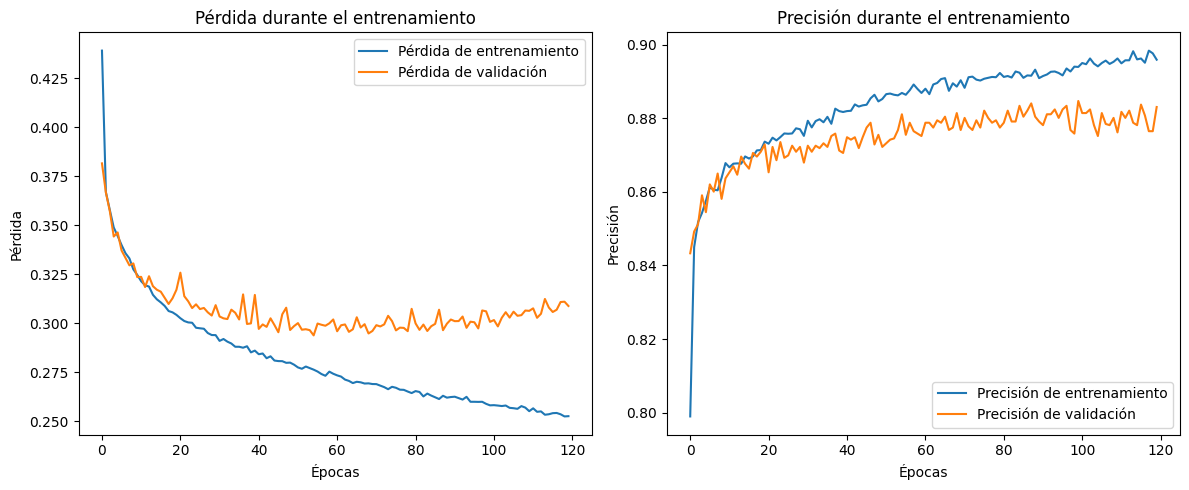

In [28]:
print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree})")
print("Acurracy en test: {:.6f}".format(modeloTest.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history)

In [2]:
# Librerías
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import backend as K

In [3]:

# ===== CAPA CHEBYSHEV =====
class ChebyshevLayer(layers.Layer):
    def __init__(self, units, degree, **kwargs):
        super(ChebyshevLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree

    def build(self, input_shape):
        self.w_cheb = self.add_weight(
            shape=(self.degree + 1, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="chebyshev_weights"
        )

    def call(self, inputs):
        inputs_cheb = tf.cast(inputs, self.compute_dtype)

        t_n_minus_1_cheb = tf.ones_like(inputs_cheb)  # T0
        t_n_cheb = inputs_cheb                        # T1
        
        output_cheb = tf.matmul(t_n_minus_1_cheb, self.w_cheb[0]) + \
                      tf.matmul(t_n_cheb, self.w_cheb[1])
        
        for i in range(2, self.degree + 1):
            t_n_plus_1_cheb = 2.0 * inputs_cheb * t_n_cheb - t_n_minus_1_cheb
            
            output_cheb += tf.matmul(t_n_plus_1_cheb, self.w_cheb[i])
            
            t_n_minus_1_cheb = t_n_cheb
            t_n_cheb = t_n_plus_1_cheb
            
        return output_cheb

In [4]:

# ===== FUNCIÓN DE PLOTEO =====
def plot_training_history_cheb(history_cheb):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history_cheb.history['loss'], label='Pérdida entrenamiento')
    plt.plot(history_cheb.history['val_loss'], label='Pérdida validación')
    plt.title('Pérdida')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history_cheb.history['accuracy'], label='Precisión entrenamiento')
    plt.plot(history_cheb.history['val_accuracy'], label='Precisión validación')
    plt.title('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [5]:
# ===== DATOS =====
magic_gamma_telescope_cheb = fetch_ucirepo(id=159)

X_cheb = magic_gamma_telescope_cheb.data.features 
y_cheb = magic_gamma_telescope_cheb.data.targets 

X_train_cheb, X_test_cheb, y_train_cheb, y_test_cheb = train_test_split(
    X_cheb, y_cheb, test_size=0.2, random_state=42
)

scaler_cheb = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled_cheb = scaler_cheb.fit_transform(X_train_cheb)
X_test_scaled_cheb = scaler_cheb.transform(X_test_cheb)

input_dim_cheb = X_train_cheb.shape[1]

y_train_cheb = (y_train_cheb == 'g').astype(int)
y_test_cheb = (y_test_cheb == 'g').astype(int)

In [6]:
# ===== MODELO =====
def PolynomialDenseCreator_cheb(degree_cheb):
    inputPoli_cheb = keras.Input(shape=(input_dim_cheb,))
    
    x_cheb = ChebyshevLayer(32, degree=degree_cheb)(inputPoli_cheb)
    x_cheb = layers.Activation('swish')(x_cheb)
    x_cheb = layers.Dense(16, activation='swish')(x_cheb)
    
    outputPoli_cheb = layers.Dense(2, activation='softmax')(x_cheb)
    
    model_cheb = keras.Model(
        inputs=inputPoli_cheb,
        outputs=outputPoli_cheb,
        name=f"Polynomial_Model_Degree_{degree_cheb}_cheb"
    )
    
    model_cheb.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model_cheb


In [7]:

# ===== PARÁMETROS =====
degree_cheb = 4
epochs_cheb = 120


def createEarlyStoppingCallback_cheb(patience_cheb=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_cheb,
        restore_best_weights=True
    )



Entrenando Grado 4 (Chebyshev) ...
Epoch 1/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7878 - loss: 0.4544 - val_accuracy: 0.8410 - val_loss: 0.3714
Epoch 2/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8515 - loss: 0.3599 - val_accuracy: 0.8502 - val_loss: 0.3568
Epoch 3/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8552 - loss: 0.3485 - val_accuracy: 0.8564 - val_loss: 0.3496
Epoch 4/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8568 - loss: 0.3433 - val_accuracy: 0.8499 - val_loss: 0.3501
Epoch 5/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8588 - loss: 0.3383 - val_accuracy: 0.8561 - val_loss: 0.3400
Epoch 6/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8620 - loss: 0.3337 - val_accuracy: 0.8630 - val_loss: 0.3308
Epoch 7/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8607 - loss: 0.3298 - val_accuracy: 0.8587 - val_loss: 0.3294
Epoch 8/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accura

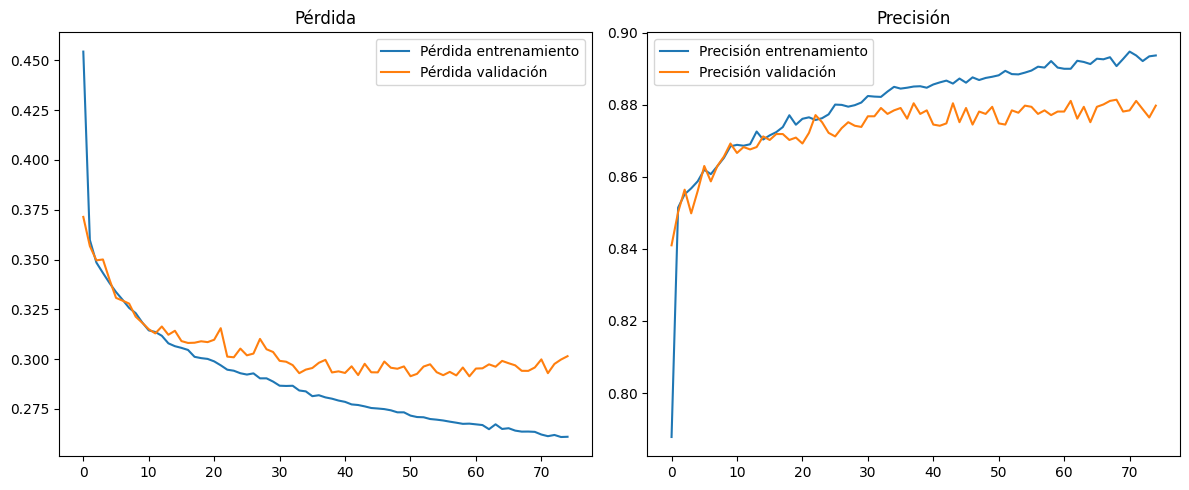

In [8]:
# ===== ENTRENAMIENTO =====
K.clear_session()

print("Entrenando Grado " + str(degree_cheb) + " (Chebyshev) ...")

modeloTest_cheb = PolynomialDenseCreator_cheb(degree_cheb)

history_cheb = modeloTest_cheb.fit(
    X_train_scaled_cheb,
    y_train_cheb,
    validation_split=0.2,
    epochs=epochs_cheb,
    batch_size=32,
    callbacks=[createEarlyStoppingCallback_cheb()]
)

print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree_cheb} - Chebyshev)")

acc_cheb = modeloTest_cheb.evaluate(
X_test_scaled_cheb,y_test_cheb,verbose=0)[1]

print("Accuracy en test: {:.6f}".format(acc_cheb))

plot_training_history_cheb(history_cheb)